In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install -U git+https://github.com/qubvel/classification_models.git

  Cloning https://github.com/qubvel/classification_models.git to /tmp/pip-req-build-0b1faze8
  Running command git clone --filter=blob:none --quiet https://github.com/qubvel/classification_models.git /tmp/pip-req-build-0b1faze8
  Resolved https://github.com/qubvel/classification_models.git to commit a0f006e05485a34ccf871c421279864b0ccd220b
  Running command git submodule update --init --recursive -q
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 2.0 MB/s eta 0:00:00
  Created wheel for image_classifiers: filename=image_classifiers-1.0.0-py3-none-any.whl size=20029 sha256=599336982395f7e575037cf539165fa8028d42593198569d8fd9d9daafdaa762
  Stored in directory: /tmp/pip-ephem-wheel-cache-ctur92u2/wheels/14/43/ed/2d68b197c5260e7fe6b7d0fab20b997b6d365f6f5732316952
Successfully built image_classifiers


In [19]:
import tensorflow as tf
from classification_models.tfkeras import Classifiers
from tensorflow.keras.layers import (Input, Conv2D, GlobalAveragePooling2D,
                                     Dense, Multiply, Add, Concatenate, Reshape,
                                     Activation, Lambda)
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
from itertools import cycle
from sklearn.metrics import roc_curve, auc

In [20]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

In [44]:
MAIN_DIR = '/kaggle/input/cassava-dataset'
TRAIN_DIR = MAIN_DIR + '/CASSAVA'
TEST_DIR = TRAIN_DIR

In [28]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# ✅ Get class names from the raw dataset BEFORE prefetch/cache
class_names = train_ds_raw.class_names
NUM_CLASSES = len(class_names)

# ✅ Only after saving class names, you cache and prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds_raw.cache().prefetch(buffer_size=AUTOTUNE)


Found 21397 files belonging to 5 classes.
Using 17118 files for training.
Found 21397 files belonging to 5 classes.
Using 4279 files for validation.


In [29]:
MobileNetV2, preprocess_input = Classifiers.get('mobilenetv2')
preprocess_layer = tf.keras.layers.Lambda(lambda x: preprocess_input(x))

In [30]:
def Cosin_similarity(tensors):
    a, b = tensors
    dot_product = tf.reduce_sum(a * b, axis=-1, keepdims=True)
    norm_a = tf.norm(a, axis=-1, keepdims=True)
    norm_b = tf.norm(b, axis=-1, keepdims=True)
    return dot_product / (norm_a * norm_b + tf.keras.backend.epsilon())

def Bund(inputs):
    alpha_1, alpha_2 = inputs
    total = alpha_1 + alpha_2 + tf.keras.backend.epsilon()
    alpha_l = alpha_1 / total
    alpha_g = alpha_2 / total
    return alpha_l, alpha_g


In [31]:
def eca_module(input_tensor, gamma=2):
    channels = input_tensor.shape[-1]
    squeeze = GlobalAveragePooling2D()(input_tensor)
    excitation = Dense(units=channels // gamma)(squeeze)
    excitation = Activation('relu')(excitation)
    excitation = Dense(units=channels)(excitation)
    excitation = Activation('sigmoid')(excitation)
    excitation = Reshape((1, 1, channels))(excitation)
    scale = Multiply()([input_tensor, excitation])
    output = Add()([scale, input_tensor])
    return output

In [32]:
def res_csa_module(input_tensor, reduction_ratio=16):
    channels = input_tensor.shape[-1]
    conv1 = Conv2D(filters=channels // reduction_ratio, kernel_size=(1,1), padding='same', activation='relu')(input_tensor)
    conv2 = Conv2D(filters=channels // reduction_ratio, kernel_size=(1,1), padding='same', activation='relu')(conv1)
    conv3 = Conv2D(filters=channels, kernel_size=(1,1), padding='same', activation='relu')(conv2)
    attention_map = Conv2D(filters=1, kernel_size=(1,1), padding='same', activation='sigmoid')(conv3)
    attention = Multiply()([attention_map, input_tensor])
    output = Add()([attention, input_tensor])
    return output


In [33]:
def build_model(input_shape, num_classes):
    input_tensor = Input(shape=input_shape)
    x = preprocess_layer(input_tensor)
    backbone_output = MobileNetV2(input_shape=input_shape, weights='imagenet', include_top=False)(x)
    eca_out = eca_module(backbone_output)
    res_csa_out = res_csa_module(backbone_output)
    x = Add()([backbone_output, eca_out, res_csa_out])
    x_l = GlobalAveragePooling2D()(eca_out)
    x_g = GlobalAveragePooling2D()(res_csa_out)
    x_c = GlobalAveragePooling2D()(x)
    x_l = Dense(384, activation='relu')(x_l)
    x_g = Dense(384, activation='relu')(x_g)
    x_c = Dense(384, activation='relu')(x_c)
    share = Dense(768, activation='relu')
    x_l = share(x_l)
    x_g = share(x_g)
    x_c = share(x_c)
    x_l = Dense(768, activation='relu')(x_l)
    x_g = Dense(768, activation='relu')(x_g)
    x_c = Dense(768, activation='relu')(x_c)
    x_l = Dense(num_classes, activation='softmax')(x_l)
    x_g = Dense(num_classes, activation='softmax')(x_g)
    x_c = Dense(num_classes, activation='softmax')(x_c)
    alpha_1 = Lambda(Cosin_similarity)([x_l, x_c])
    alpha_2 = Lambda(Cosin_similarity)([x_g, x_c])
    alpha_l, alpha_g = Lambda(Bund)([alpha_1, alpha_2])
    out_l = Multiply()([alpha_l, x_l])
    out_g = Multiply()([alpha_g, x_g])
    out = Concatenate()([out_l, out_g])
    out = Dense(64, activation='relu')(out)
    out = Dense(num_classes, activation='softmax')(out)
    model = Model(inputs=input_tensor, outputs=out)
    return model

In [34]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay

lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-4,
    decay_steps=100000,
    decay_rate=0.96,
    staircase=True
)

In [37]:
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model = build_model(input_shape=IMG_SIZE + (3,), num_classes=NUM_CLASSES)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda (Lambda)           │ (None, 128, 128, 3)    │              0 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ mobilenetv2_1.00_128      │ (None, 4, 4, 1280)     │      2,257,984 │ lambda[1][0]           │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 1280)           │              0 │ mobilenetv2_1.00_128[… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_14 (Dense)          │ (None, 640)            │        819,840 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 640)            │              0 │ dense_14[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 4, 4, 80)       │        102,480 │ mobilenetv2_1.00_128[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_15 (Dense)          │ (None, 1280)           │        820,480 │ activation_2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 4, 4, 80)       │          6,480 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 1280)           │              0 │ dense_15[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 4, 4, 1280)     │        103,680 │ conv2d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_1 (Reshape)       │ (None, 1, 1, 1280)     │              0 │ activation_3[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 4, 4, 1)        │          1,281 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_4 (Multiply)     │ (None, 4, 4, 1280)     │              0 │ mobilenetv2_1.00_128[… │
│                           │                        │                │ reshape_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_5 (Multiply)     │ (None, 4, 4, 1280)     │              0 │ conv2d_7[0][0],        │
│                           │                        │                │ mobilenetv2_1.00_128[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_3 (Add)               │ (None, 4, 4, 1280)     │              0 │ multiply_4[0][0],      │
│                           │                        │                │ mobilenetv2_1.00_128[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_4 (Add)          

 Total params: 7,667,957 (29.25 MB)

 Trainable params: 7,633,845 (29.12 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [38]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100
)

Epoch 1/100


I0000 00:00:1745854014.380033     171 service.cc:148] XLA service 0x796fa4001360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745854014.383136     171 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1745854014.383159     171 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1745854018.444718     171 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/535 ━━━━━━━━━━━━━━━━━━━━ 34s 64ms/step - accuracy: 0.4141 - loss: 1.5790   

I0000 00:00:1745854036.940410     171 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


535/535 ━━━━━━━━━━━━━━━━━━━━ 138s 138ms/step - accuracy: 0.6151 - loss: 1.3651 - val_accuracy: 0.5948 - val_loss: 1.1780
Epoch 2/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - accuracy: 0.6715 - loss: 1.0254 - val_accuracy: 0.6812 - val_loss: 0.9366
Epoch 3/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy: 0.7011 - loss: 0.8584 - val_accuracy: 0.7235 - val_loss: 0.8252
Epoch 4/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - accuracy: 0.7526 - loss: 0.7524 - val_accuracy: 0.7467 - val_loss: 0.8032
Epoch 5/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - accuracy: 0.7726 - loss: 0.6854 - val_accuracy: 0.7387 - val_loss: 0.7339
Epoch 6/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - accuracy: 0.7928 - loss: 0.6192 - val_accuracy: 0.7633 - val_loss: 0.7335
Epoch 7/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - accuracy: 0.8231 - loss: 0.5554 - val_accuracy: 0.7572 - val_loss: 0.7057
Epoch 8/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - accuracy: 0.8434 - loss: 0.4946 - va

Found 21397 files belonging to 5 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━

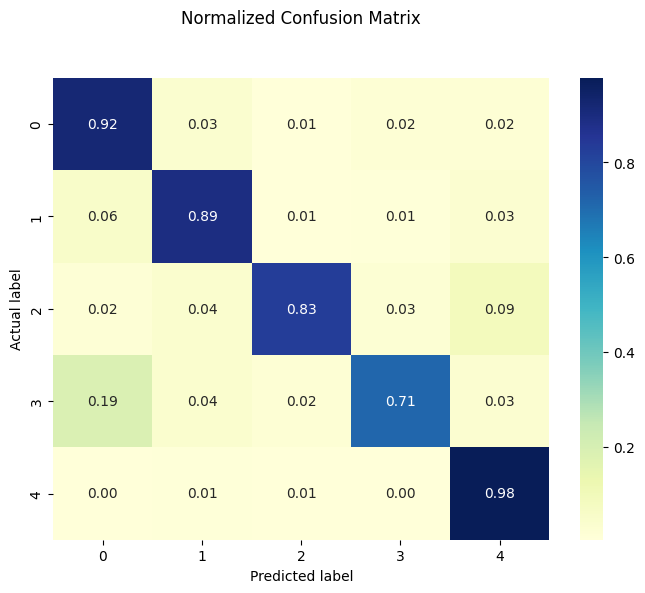

In [49]:
# Generate predictions and true labels
y_true = []
y_pred = []

if TEST_DIR:
    test_ds = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        label_mode='categorical'  # if labeled
    )
    for images, labels in test_ds:
        preds = model.predict(images)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=-1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # 🛠️ FIX: Convert one-hot encoded labels to integers
    y_true = np.argmax(y_true, axis=1)
    
    # Now confusion matrix will work
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(pd.DataFrame(cm), annot=True, fmt='.2f', cmap="YlGnBu",
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Normalized Confusion Matrix', y=1.1)
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()
else:
    print("Nothing provided")


In [50]:
if TEST_DIR:
    test_ds = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        label_mode='categorical'  # if labeled
    )
    test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)
    test_loss, test_acc = model.evaluate(test_ds)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    # Report metrics if you have labels
    y_true = np.concatenate([y for x, y in test_ds], axis=0)
    y_pred_probs = model.predict(test_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true_classes = np.argmax(y_true, axis=1) # Convert to class indices

    print(classification_report(y_true_classes, y_pred, target_names=class_names))
else:
    print("No test directory provided. Skipping evaluation.")

Found 21397 files belonging to 5 classes.
669/669 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.8836 - loss: 0.5799
Test Loss: 0.3979
Test Accuracy: 0.9180
669/669 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step
              precision    recall  f1-score   support

           0       0.58      0.92      0.71      1087
           1       0.85      0.89      0.87      2189
           2       0.93      0.83      0.88      2386
           3       0.92      0.71      0.80      2577
           4       0.97      0.98      0.97     13158

    accuracy                           0.92     21397
   macro avg       0.85      0.87      0.85     21397
weighted avg       0.93      0.92      0.92     21397



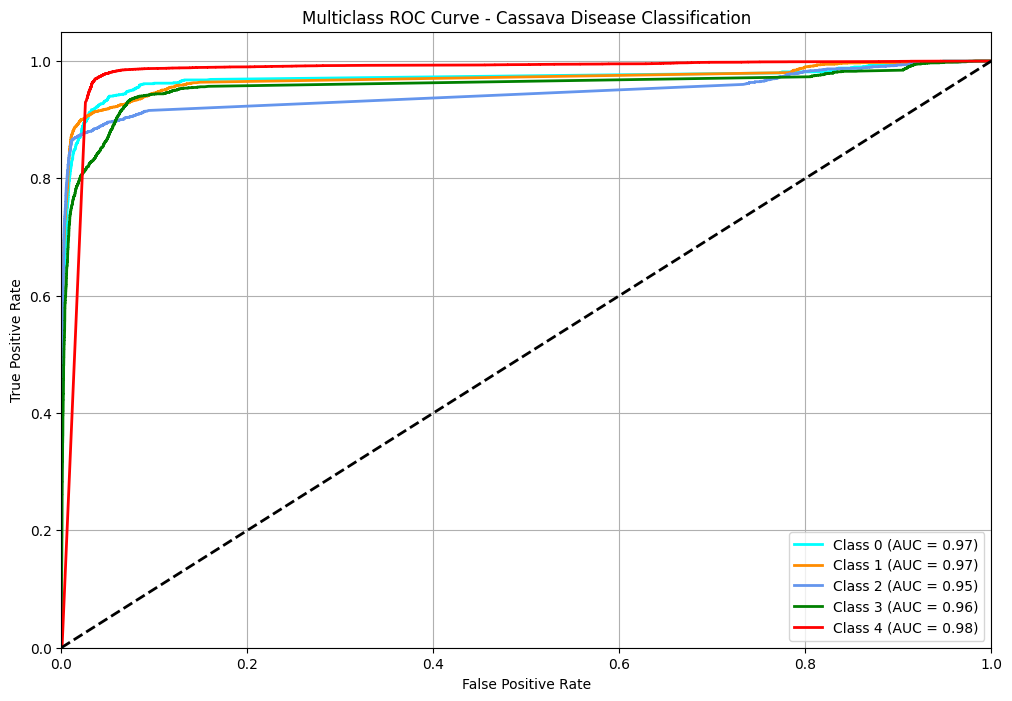

In [52]:
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true_classes, classes=list(range(NUM_CLASSES)))

# Predict probabilities if not already done
# y_pred_probs = model.predict(test_ds)  # you already have it

# ROC Curve and AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(12, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])

for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Random line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve - Cassava Disease Classification')
plt.legend(loc="lower right")
plt.grid()
plt.show()
